# 2-3. 일원분산분석(ANOVA)

세 지점 A, B, C의 일별 판매량 평균에 차이가 있는지 확인한다.

In [6]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

# macOS의 한글 폰트를 그래프 기본 글꼴로 설정한다.
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

# 지점별 일별 판매량 데이터를 읽는다.
sales_df = pd.read_csv(
    "datas2/지점별_일별판매량.csv",
    encoding="euc-kr"
)

# 데이터 앞부분과 열 이름을 확인한다.
print(sales_df.head())
print(sales_df.columns)

   일자  지점A  지점B  지점C
0   1  124  118  216
1   2  147  141  214
2   3  129  130  212
3   4  123  127  179
4   5  147  107  222
Index(['일자', '지점A', '지점B', '지점C'], dtype='str')


## 1. 데이터 분리와 가설 설정

세 지점의 일별 판매량 평균이 같은지 확인한다.

- 귀무가설(H₀): 지점 A, B, C의 평균 판매량은 모두 같다.
- 대립가설(H₁): 세 지점 중 적어도 하나의 평균 판매량은 다르다.

In [7]:
# 각 지점의 판매량 열에서 결측값을 제거하고 NumPy 배열로 변환한다.
branch_a = sales_df["지점A"].dropna().to_numpy()
branch_b = sales_df["지점B"].dropna().to_numpy()
branch_c = sales_df["지점C"].dropna().to_numpy()

# 각 지점의 데이터 개수와 평균 판매량을 확인한다.
print(f"지점 A - 개수: {len(branch_a)}, 평균: {np.mean(branch_a):.2f}")
print(f"지점 B - 개수: {len(branch_b)}, 평균: {np.mean(branch_b):.2f}")
print(f"지점 C - 개수: {len(branch_c)}, 평균: {np.mean(branch_c):.2f}")

지점 A - 개수: 30, 평균: 137.87
지점 B - 개수: 30, 평균: 136.47
지점 C - 개수: 30, 평균: 200.10


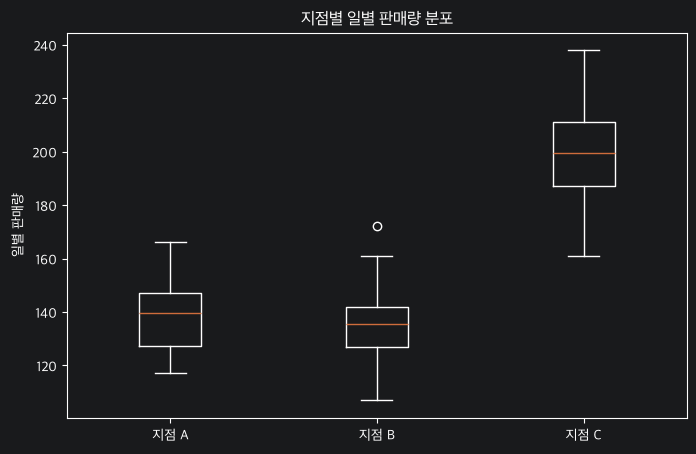

In [8]:
# 지점별 판매량 분포를 상자그림으로 확인한다.
plt.figure(figsize=(8, 5))

# 중앙선은 중앙값, 상자는 데이터가 주로 분포한 범위를 의미한다.
plt.boxplot([branch_a, branch_b, branch_c])

# x축 눈금에 각 지점 이름을 표시한다.
plt.xticks([1, 2, 3], ["지점 A", "지점 B", "지점 C"])

plt.ylabel("일별 판매량")
plt.title("지점별 일별 판매량 분포")
plt.show()

### 1-1. 정규성 검정

ANOVA를 적용하기 전에 각 지점의 판매량 분포가 정규분포에서 크게 벗어나지 않는지 확인한다.

- 귀무가설(H₀): 해당 지점의 판매량은 정규분포를 따른다.
- 대립가설(H₁): 해당 지점의 판매량은 정규분포를 따르지 않는다.

In [9]:
# 각 지점 판매량에 Shapiro-Wilk 정규성 검정을 수행한다.
normality_a = stats.shapiro(branch_a)
normality_b = stats.shapiro(branch_b)
normality_c = stats.shapiro(branch_c)

# 지점별 p-value를 출력한다.
print(f"지점 A p-value: {normality_a.pvalue:.4f}")
print(f"지점 B p-value: {normality_b.pvalue:.4f}")
print(f"지점 C p-value: {normality_c.pvalue:.4f}")

# 세 지점 모두의 정규성 검정 결과를 함께 해석한다.
if all(result.pvalue > 0.05 for result in [normality_a, normality_b, normality_c]):
    print("세 지점 모두 정규성을 위반한다고 볼 충분한 증거가 없다.")
else:
    print("적어도 한 지점은 정규성을 위반할 가능성이 있다.")

지점 A p-value: 0.4219
지점 B p-value: 0.8099
지점 C p-value: 0.8772
세 지점 모두 정규성을 위반한다고 볼 충분한 증거가 없다.


### 1-2. 등분산성 검정

세 지점의 판매량 분산이 같은지 확인한다.

- 귀무가설(H₀): 세 지점의 판매량 분산은 같다.
- 대립가설(H₁): 세 지점 중 적어도 하나의 판매량 분산은 다르다.

In [10]:
# Levene 검정으로 세 지점의 등분산성을 확인한다.
# center="median"은 이상치 영향이 비교적 적은 중앙값 기준 검정이다.
variance_result = stats.levene(
    branch_a,
    branch_b,
    branch_c,
    center="median"
)

print(f"검정통계량: {variance_result.statistic:.4f}")
print(f"p-value: {variance_result.pvalue:.4f}")

# 유의수준 0.05를 기준으로 결과를 해석한다.
if variance_result.pvalue > 0.05:
    print("등분산성을 위반한다고 볼 충분한 증거가 없다.")
else:
    print("지점 간 판매량 분산이 다를 가능성이 있다.")

검정통계량: 1.2446
p-value: 0.2931
등분산성을 위반한다고 볼 충분한 증거가 없다.


## 2. 일원분산분석 수행

유의수준 0.05에서 세 지점의 평균 판매량이 모두 같은지 검정한다.

- 귀무가설(H₀): 지점 A, B, C의 평균 판매량은 모두 같다.
- 대립가설(H₁): 세 지점 중 적어도 하나의 평균 판매량은 다르다.

In [11]:
# 세 지점의 평균 판매량 차이에 대해 일원분산분석을 수행한다.
anova_result = stats.f_oneway(
    branch_a,
    branch_b,
    branch_c
)

print(f"F-통계량: {anova_result.statistic:.4f}")
print(f"p-value: {anova_result.pvalue:.4f}")

# 유의수준 0.05를 기준으로 검정 결과를 해석한다.
if anova_result.pvalue <= 0.05:
    print("귀무가설을 기각한다: 세 지점 중 적어도 하나의 평균 판매량은 다르다.")
else:
    print("귀무가설을 기각하지 못한다: 평균 판매량이 다르다고 할 충분한 증거가 없다.")

F-통계량: 178.4383
p-value: 0.0000
귀무가설을 기각한다: 세 지점 중 적어도 하나의 평균 판매량은 다르다.


## 3. Tukey 사후검정

ANOVA는 평균이 다른 지점이 적어도 하나 있다는 것만 알려준다.
Tukey 사후검정으로 어떤 지점 쌍의 평균 판매량이 다른지 확인한다.

- 여러 쌍을 동시에 비교하므로, p-value가 다중 비교에 맞게 보정된다.

In [12]:
# 모든 지점 쌍을 비교하는 Tukey 사후검정을 수행한다.
tukey_result = stats.tukey_hsd(
    branch_a,
    branch_b,
    branch_c
)

# 결과 행렬에서 각 지점 쌍의 평균 차이와 보정 p-value를 꺼낸다.
tukey_summary = pd.DataFrame({
    "비교": ["A - B", "A - C", "B - C"],
    "평균 차이(앞 지점 - 뒤 지점)": [
        tukey_result.statistic[0, 1],
        tukey_result.statistic[0, 2],
        tukey_result.statistic[1, 2]
    ],
    "보정 p-value": [
        tukey_result.pvalue[0, 1],
        tukey_result.pvalue[0, 2],
        tukey_result.pvalue[1, 2]
    ]
})

# 보정 p-value가 0.05 이하인지로 유의한 차이를 표시한다.
tukey_summary["유의한 차이"] = tukey_summary["보정 p-value"] <= 0.05

# 숫자를 보기 좋게 반올림해 출력한다.
tukey_summary.round(4)

,비교,평균 차이(앞 지점 - 뒤 지점),보정 p-value,유의한 차이
0,A - B,1.4000,0.9297,False
1,A - C,-62.2333,0.0000,True
2,B - C,-63.6333,0.0000,True


## 4. 분석 결과

- 세 지점의 평균 판매량은 모두 같다는 귀무가설을 기각했다.
- 지점 A와 B의 평균 판매량 차이는 통계적으로 유의하지 않았다.
- 지점 C의 평균 판매량은 지점 A보다 약 62.23, 지점 B보다 약 63.63 높았으며 두 차이 모두 통계적으로 유의했다.
- 따라서 세 지점의 평균 차이는 주로 지점 C의 높은 판매량에서 비롯된 것으로 해석할 수 있다.